In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv('./DataSet/trx-10k.csv')
df.dropna(inplace=True)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 9578 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   status     9578 non-null   object
 1   time       9578 non-null   object
 2   card_type  9578 non-null   object
 3   city       9578 non-null   object
 4   amount     9578 non-null   int64 
 5   id         9578 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 523.8+ KB


,amount,id
count,9.578000e+03,9578.000000
mean,2.492398e+06,50.050324
std,1.442460e+06,28.917290
min,1.048100e+04,1.000000
25%,1.247962e+06,25.000000
50%,2.471254e+06,50.000000
75%,3.747052e+06,74.750000
max,4.997913e+06,100.000000


In [80]:
df.head()

,status,time,card_type,city,amount,id
0,success,2025-09-07 10:48:00,Visa,Tehran,470243,98
1,success,2025-09-20 13:10:00,MastCard,Tehran,4025070,52
2,fail,2025-09-29 03:27:00,Visa,Tehran,3573895,20
3,success,2025-09-15 13:13:00,Discover,Isfahan,4961173,40
4,success,2025-09-11 11:11:00,Visa,Tehran,2067746,59


In [81]:
# Lets Wash The Dirty Data :)
# Status Col

df['status'] = df['status'].str.lower().str.strip()
df['status'].unique()


array(['success', 'fail', 'failed', 'succeed'], dtype=object)

In [82]:
def status_cleaner(x:str):
    if x in ['success','succeed']:
        return 'success'
    
    elif x in ['fail','failed']:
        return 'fail'
    
    return np.nan

df['status'] = df['status'].apply(status_cleaner)

df['status'].dropna(inplace=True)
df['status'].unique()

array(['success', 'fail'], dtype=object)

In [83]:
# Time Col

df['time'] = pd.to_datetime(df['time'],errors='coerce',format='%Y-%m-%d %H:%M:%S')
df['time'].isnull().sum()

np.int64(0)

In [84]:
# Card Type Col

df['card_type'] = df['card_type'].str.lower().str.strip()
df['card_type'].unique()

array(['visa', 'mastcard', 'discover', 'master-card', 'amex',
       'mastercard', 'vsa', 'master card'], dtype=object)

In [85]:
def clean_CardType(x:str):
    if x in ['mastcard','master-card','mastercard','master card']:
        return "MasterCard"
    elif x in ['visa','vsa']:
        return "Visa"
    elif x == 'discover':
        return "Discover"
    elif x == 'amex':
        return 'Amex'
    
    return np.nan

df['card_type'] = df['card_type'].apply(clean_CardType)

df['card_type'].isnull().sum()


np.int64(0)

In [86]:
# City Col

df['city'] = df['city'].str.lower().str.strip()

df['city'].unique()

array(['tehran', 'isfahan', 'tabriz', 'shiraz', 'karaj', 'ahvaz', 'thr',
       'qom', 'mashhad', 'tehr@n', 'thran'], dtype=object)

In [87]:
def clean_city(x:str):
    if x in ['tehran','thr','tehr@n','thran']:
        return "Tehran"
    
    elif x in ['mashhad','qom','ahvaz','karaj','shiraz','tabriz','isfahan']:
        return x.capitalize()
    
    return np.nan

df['city'] = df['city'].apply(clean_city)
df['city'].isnull().sum()

np.int64(0)

In [88]:
df['city'].unique()

array(['Tehran', 'Isfahan', 'Tabriz', 'Shiraz', 'Karaj', 'Ahvaz', 'Qom',
       'Mashhad'], dtype=object)

In [89]:
# Id Col Moving

cols = ['id'] + [col for col in df.columns if col != 'id']
df = df.reindex(columns=cols)

df.head()

,id,status,time,card_type,city,amount
0,98,success,2025-09-07 10:48:00,Visa,Tehran,470243
1,52,success,2025-09-20 13:10:00,MasterCard,Tehran,4025070
2,20,fail,2025-09-29 03:27:00,Visa,Tehran,3573895
3,40,success,2025-09-15 13:13:00,Discover,Isfahan,4961173
4,59,success,2025-09-11 11:11:00,Visa,Tehran,2067746


In [90]:
df = df.sort_values(by='id')
df

,id,status,time,card_type,city,amount
9964,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069
9990,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633
8965,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320
2275,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108
5372,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093
...,...,...,...,...,...,...
1065,100,fail,2025-09-28 03:00:00,MasterCard,Tehran,294175
3751,100,fail,2025-09-24 13:13:00,Amex,Mashhad,4035709
5310,100,success,2025-09-28 20:20:00,Amex,Mashhad,703002
5715,100,success,2025-09-29 13:13:00,MasterCard,Ahvaz,4245781


In [91]:
"Duplicated Transctions Percentage : " + str((df['id'].duplicated().sum() / len(df['id'])).round(2) * 100)

# So Its Not Outlier And Its Normal Because A Person Can Have Transactions More Than One

'Duplicated Transctions Percentage : 99.0'

In [92]:
df = df.reset_index(drop=True)
df.head()

,id,status,time,card_type,city,amount
0,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069
1,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633
2,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320
3,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108
4,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093


In [93]:
df['amount'].describe()

count    9.578000e+03
mean     2.492398e+06
std      1.442460e+06
min      1.048100e+04
25%      1.247962e+06
50%      2.471254e+06
75%      3.747052e+06
max      4.997913e+06
Name: amount, dtype: float64

In [94]:
df['time'].describe()

count                             9578
mean     2025-09-16 05:08:47.546460416
min                2025-09-01 00:00:00
25%                2025-09-08 14:55:00
50%                2025-09-16 08:59:00
75%                2025-09-23 16:40:00
max                2025-09-30 23:59:00
Name: time, dtype: object

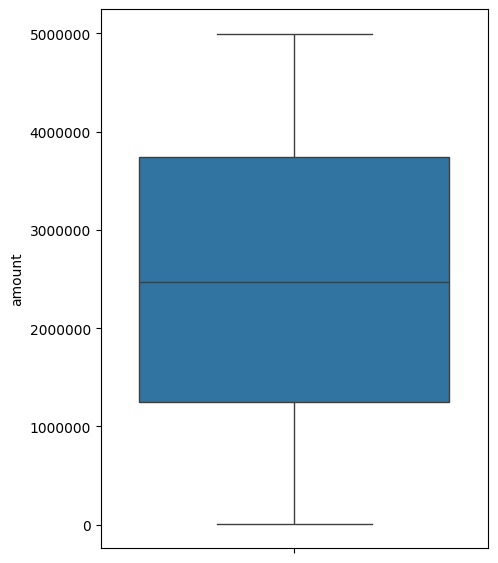

In [95]:

plt.figure(figsize=(5,7))
sns.boxplot(df['amount'])
plt.ticklabel_format(style='plain', axis='y')


In [96]:
q1 = df['amount'].quantile(0.25)
q3 = df['amount'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df[(df['amount'] > upper_bound) | (df['amount'] < lower_bound)]

,id,status,time,card_type,city,amount


In [97]:
# By Z Score

mean = df['amount'].mean()
std = df['amount'].std()

df['z_score'] = abs((df['amount'] - mean) / std)
df[df['z_score'] > 3]

,id,status,time,card_type,city,amount,z_score


In [98]:
df.iloc[df['z_score'].idxmax()]

id                            62
status                      fail
time         2025-09-29 14:00:00
card_type               Discover
city                     Isfahan
amount                   4997913
z_score                 1.736974
Name: 5962, dtype: object

In [99]:
df.head()

,id,status,time,card_type,city,amount,z_score
0,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069,0.312195
1,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633,0.851486
2,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320,1.588314
3,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108,1.430688
4,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093,0.250748


<Axes: ylabel='transactions'>

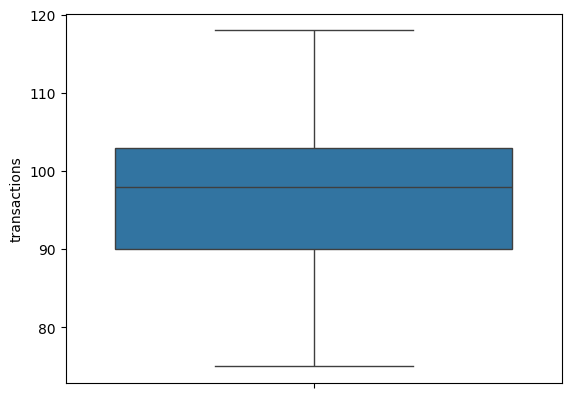

In [100]:
# Hackers Or People That Have Big Values Transactions

# groupby_id = df[df['status'] != 'fail'].groupby('id')

df['transactions'] = df.groupby('id').transform('size')
sns.boxplot(df['transactions'])

In [101]:
q1_trc = df['transactions'].quantile(0.25)
q3_trc = df['transactions'].quantile(0.75)

IQR_trc = q3_trc - q1_trc

lower_bound_trc = q1_trc - 1.5 * IQR_trc
upper_bound_trc = q3_trc + 1.5 * IQR_trc

df[(df['transactions'] > upper_bound_trc) | (df['transactions'] < lower_bound_trc)]

,id,status,time,card_type,city,amount,z_score,transactions


In [102]:
mean_trc = df['transactions'].mean()
std_trc = df['transactions'].std()

df['z_score_trc'] = abs((df['transactions'] - mean_trc) / std_trc)
df[df['z_score_trc'] > 3]


,id,status,time,card_type,city,amount,z_score,transactions,z_score_trc


In [103]:
df.drop(columns='z_score_trc')

,id,status,time,card_type,city,amount,z_score,transactions
0,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069,0.312195,102
1,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633,0.851486,102
2,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320,1.588314,102
3,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108,1.430688,102
4,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093,0.250748,102
...,...,...,...,...,...,...,...,...
9573,100,fail,2025-09-28 03:00:00,MasterCard,Tehran,294175,1.523941,91
9574,100,fail,2025-09-24 13:13:00,Amex,Mashhad,4035709,1.069916,91
9575,100,success,2025-09-28 20:20:00,Amex,Mashhad,703002,1.240517,91
9576,100,success,2025-09-29 13:13:00,MasterCard,Ahvaz,4245781,1.215550,91


In [104]:
df[df['id'] == 10]

,id,status,time,card_type,city,amount,z_score,transactions,z_score_trc
885,10,fail,2025-09-22 00:00:00,Discover,Ahvaz,4655306,1.499458,118,2.135624
886,10,fail,2025-09-23 14:11:00,MasterCard,Tehran,568673,1.333642,118,2.135624
887,10,success,2025-09-17 07:32:00,MasterCard,Tehran,4126410,1.132795,118,2.135624
888,10,fail,2025-09-26 13:13:00,Discover,Mashhad,4251400,1.219446,118,2.135624
889,10,success,2025-09-28 09:00:00,MasterCard,Tehran,4602324,1.462727,118,2.135624
...,...,...,...,...,...,...,...,...,...
998,10,success,2025-09-03 07:32:00,MasterCard,Tehran,719509,1.229074,118,2.135624
999,10,fail,2025-09-14 14:55:00,MasterCard,Mashhad,3529081,0.718691,118,2.135624
1000,10,fail,2025-09-08 10:48:00,Discover,Mashhad,2517028,0.017075,118,2.135624
1001,10,fail,2025-09-18 21:21:00,MasterCard,Tehran,607250,1.306898,118,2.135624


<Axes: xlabel='city', ylabel='transactions'>

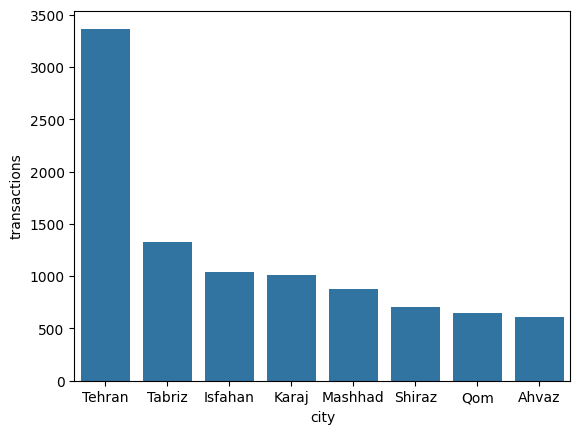

In [105]:
# Now Lets See BarPlot Of Transactions
sns.barplot(df.groupby('city')['transactions'].count().sort_values(ascending=False))



In [106]:
percentage = df.groupby('city')['transactions'].count() / df['transactions'].count() * 100

rounded = percentage.round(2).sort_values(ascending=False)
rounded = rounded.apply(lambda x : f"{x}%")

rounded

city
Tehran     35.16%
Tabriz     13.83%
Isfahan    10.83%
Karaj      10.54%
Mashhad     9.14%
Shiraz      7.37%
Qom         6.74%
Ahvaz       6.38%
Name: transactions, dtype: object

In [107]:
(percentage - percentage.mean()).sort_values(ascending=False).apply(lambda x : f"{x:.2f} %")

city
Tehran     22.66 %
Tabriz      1.33 %
Isfahan    -1.67 %
Karaj      -1.96 %
Mashhad    -3.36 %
Shiraz     -5.13 %
Qom        -5.76 %
Ahvaz      -6.12 %
Name: transactions, dtype: object

پیشنهاد استراتژیک 

وابستگی به شهر تهران بسیار زیاد است در حالی که میتوان یافت که شهر تهران 
بیست و دو درصد از میانگین بیشتر است و اگر این وابستگی حفظ شود با کوچکترین مشکل در دیتا سنتر های مربوطه , تراکنش های زیادی از دست خواهیم داد و درآمد از کارمزد کم میشود



============================================================

همچنین شهرهای قم , اهواز و شیراز نیز توانایی رشد پنج الی شش درصدی خواهند داشت چرا که اختلاف آنها از میانگین تراکنش ها , بیشترین است


In [108]:
df.head()

,id,status,time,card_type,city,amount,z_score,transactions,z_score_trc
0,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069,0.312195,102,0.45473
1,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633,0.851486,102,0.45473
2,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320,1.588314,102,0.45473
3,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108,1.430688,102,0.45473
4,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093,0.250748,102,0.45473


<Axes: xlabel='city'>

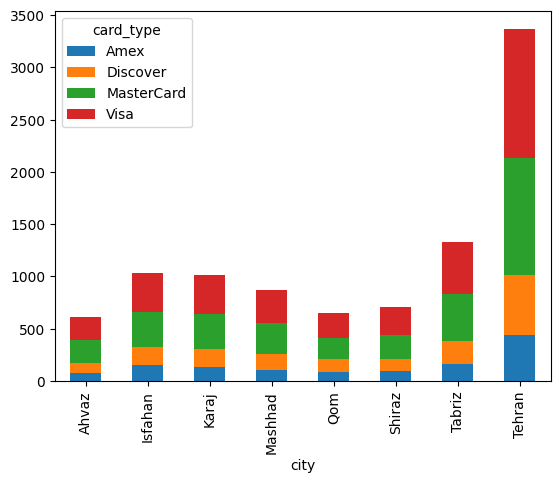

In [109]:
city_card_pivot = pd.crosstab(df['city'], df['card_type'])
city_card_pivot.plot(kind='bar',stacked=True)

<Axes: xlabel='card_type'>

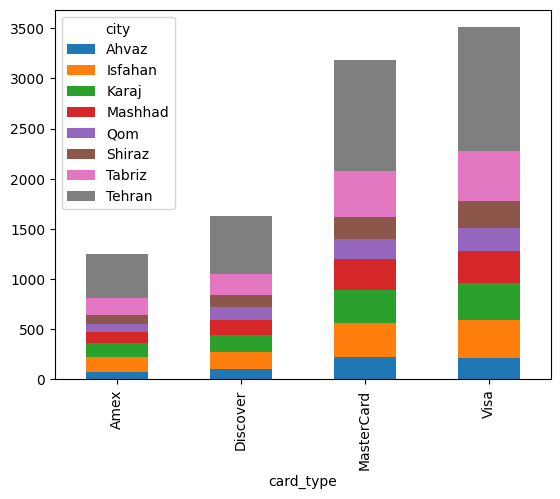

In [110]:
card_city_pivot = pd.crosstab(df['card_type'],df['city'] )
card_city_pivot.plot(kind='bar',stacked=True)

In [111]:
# Percentage Of Each Above Plots

city_card_percentage = city_card_pivot.div(city_card_pivot.sum(axis=1),axis=0) * 100
city_card_percentage.applymap(lambda x : f'{x:.2f}%')


C:\Users\Mostafa\AppData\Local\Temp\ipykernel_18172\946929550.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  city_card_percentage.applymap(lambda x : f'{x:.2f}%')


card_type,Amex,Discover,MasterCard,Visa
city,,,,
Ahvaz,11.95%,16.53%,36.33%,35.19%
Isfahan,14.56%,16.49%,32.98%,35.97%
Karaj,13.47%,17.13%,32.48%,36.93%
Mashhad,12.34%,16.69%,34.63%,36.34%
Qom,13.16%,19.50%,30.96%,36.38%
Shiraz,13.03%,17.42%,32.15%,37.39%
Tabriz,12.45%,16.08%,34.04%,37.43%
Tehran,13.00%,17.19%,33.11%,36.70%


In [112]:
# Percentage Of Each Above Plots

card_city_percentage = card_city_pivot.div(city_card_pivot.sum(axis=0),axis=0) * 100
card_city_percentage.applymap(lambda x : f'{x:.2f}%')


C:\Users\Mostafa\AppData\Local\Temp\ipykernel_18172\410488497.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  card_city_percentage.applymap(lambda x : f'{x:.2f}%')


city,Ahvaz,Isfahan,Karaj,Mashhad,Qom,Shiraz,Tabriz,Tehran
card_type,,,,,,,,
Amex,5.85%,12.10%,10.90%,8.65%,6.81%,7.37%,13.22%,35.10%
Discover,6.19%,10.48%,10.60%,8.95%,7.72%,7.54%,13.05%,35.48%
MasterCard,6.96%,10.73%,10.29%,9.50%,6.27%,7.12%,14.15%,34.97%
Visa,6.13%,10.63%,10.63%,9.06%,6.70%,7.52%,14.13%,35.21%


پیشنهاد استراتژیک : 

تراکنش ها بیشتر توسط مستر کارد و ویزا انجام شده
پس میتوان دریافت سهام های این دو شرکت رشد خواهند کرد
برای سرمایه گذاری و همکاری , قطعا ویزا و مستر کارد گزینه خوبی است
زیرا در بیشتر شهر ها مرسوم تر و مورد استفاده تر هستند (همانند تصویر چارت)
و در چارت دیگر دامنه بیشتری از شهر ها را پوشش میدهد


<Axes: xlabel='amount', ylabel='Count'>

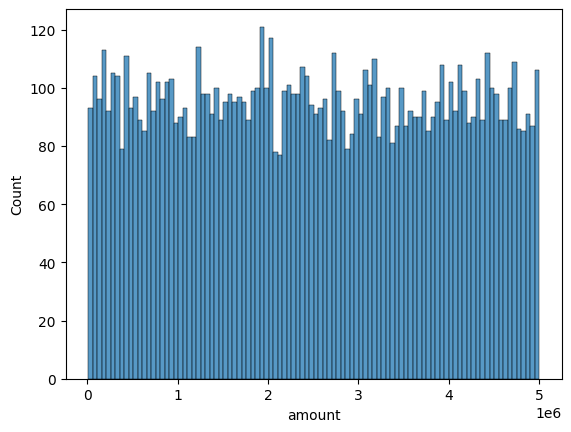

In [113]:
# Hist Of Amount

sns.histplot(df['amount'],bins=100)

<Axes: xlabel='amount', ylabel='Density'>

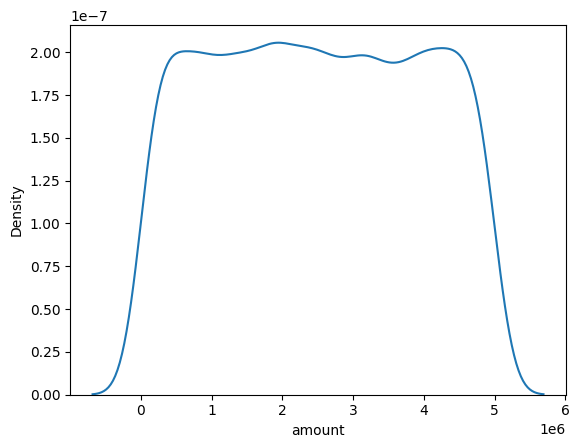

In [114]:
sns.kdeplot(df['amount'])

<Axes: ylabel='amount'>

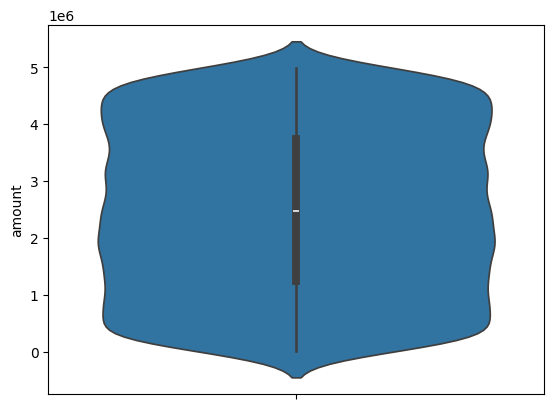

In [115]:
sns.violinplot(df['amount'])

<Axes: xlabel='amount', ylabel='Proportion'>

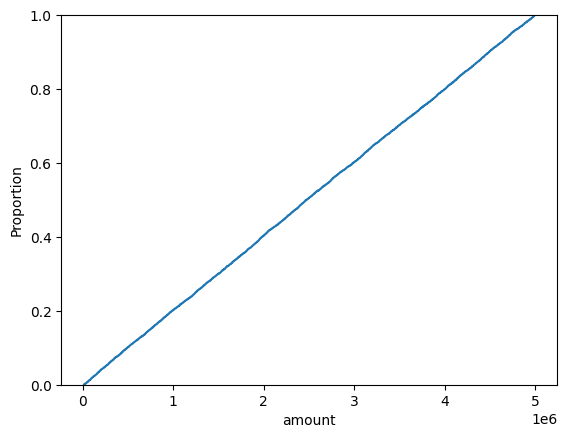

In [116]:
sns.ecdfplot(df['amount'])

توزیع نرمالی دارد تا اینکه در وسط توزیع مقداری نا هماهنگی مشاهده میشود که میفهمیم تراکنش های وسط توزیع اختلاف قابل توجهی دارند .
همچنین از نمودار ecdf میفهمیم داده ها با شیب ثابتی پیمایش میشوند و این یعنی داده پرت و یا تراکنش های خیلی بزرگ یا کوچک به نسبت داده ها نداریم
در نتیجه میتوان گفت این ستون نسبتا یک نواخت و طبیعی است اما در تراکنش های بازه نرمال (تراکنش های بین توزیعی) میفهمیم اختلاف قابل توجهی وجود دارد
طبیعی است اما اغراق شده و جامعه تراکنش های غول آسا و یا ناچیز زیادی دارد و این حد از نرمال بودن این ستون نشان میدهد samplizing یا به درستی انجام نشده یا دیتاست یک دپارتمان یا طبقه به خصوصی از جامعه میباشد

<Axes: xlabel='amount', ylabel='time_num'>

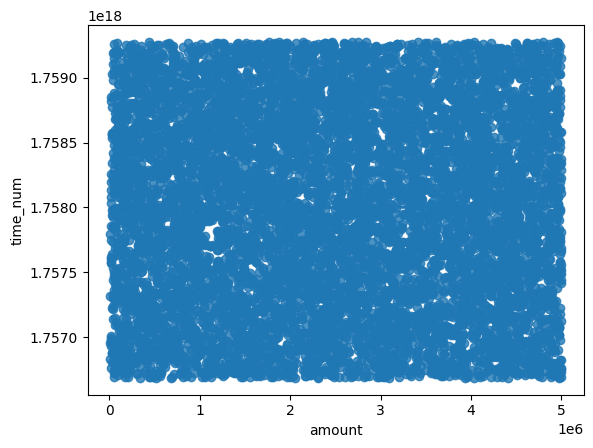

In [117]:
# Corr

# we must use corr method by the data shape and kind
# first thing i do is a scatter plot

df["time_num"] = df["time"].astype("int64")
sns.regplot(data=df, x="amount", y="time_num")

In [118]:

print(df["amount"].corr(df["time"], method="pearson"))
print(df["amount"].corr(df["time"],method="spearman"))
print(df["amount"].corr(df["time"], method="kendall"))

0.007219937976005907
0.00734343146206645
0.004885985848601233


همبستگی بسیار کمی دارد پس نتیجه میگیریم که تورم به صورت زیاد نداشتیم
زیرا با افزایش تایم , باید مبلغ تراکنش ها بیشتر شود زیرا پول بی ارزش میشود و باید مقادیر بیشتری جا به جا شود تا با آن ارزش برابری کند.
اما این همبستگی نشان میدهد که تورم بسیار کمی بوده ولی مثبت بوده
اما نرخ تورم خیلی کم است و قابل توجه نیست

<Axes: xlabel='amount', ylabel='Count'>

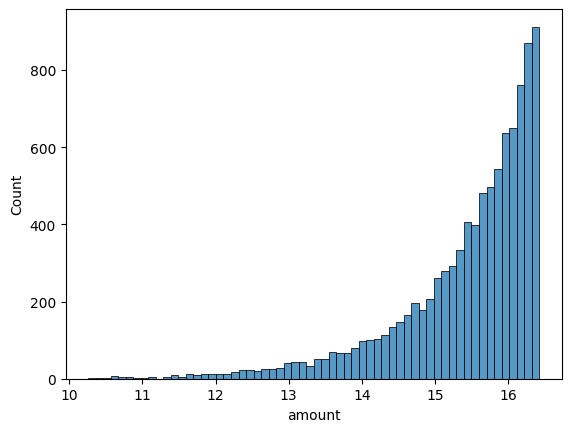

In [119]:
# log hist of amount

sns.histplot(np.log(df['amount']) + 1)

In [120]:
df.head()

,id,status,time,card_type,city,amount,z_score,transactions,z_score_trc,time_num
0,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069,0.312195,102,0.45473,1756984260000000000
1,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633,0.851486,102,0.45473,1758620700000000000
2,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320,1.588314,102,0.45473,1758293700000000000
3,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108,1.430688,102,0.45473,1757401680000000000
4,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093,0.250748,102,0.45473,1758892380000000000


<Axes: xlabel='time', ylabel='Count'>

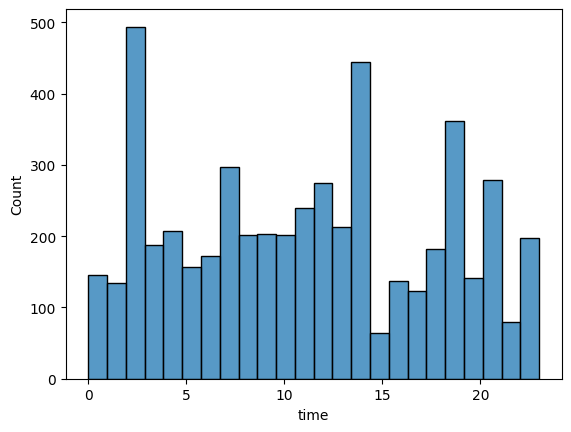

In [121]:
sns.histplot(df[df['status'] == 'fail']['time'].dt.hour,bins=24)

In [122]:
df['hour'] = df['time'].dt.hour
df[df['status'] == 'fail'].groupby('hour').size().sort_values(ascending=False)

hour
2     494
14    444
19    361
7     297
21    279
12    275
11    239
13    213
4     208
9     203
10    202
8     201
23    198
3     187
18    182
6     172
5     157
0     146
20    141
16    137
1     134
17    123
22     80
15     64
dtype: int64

از هیستوگرام میتوان نتیجه گرفت تراکنش های نا موفق بیشتر در ساعات 12 تا 4 صبح که معمولا وقت برطرف کردن باگ ها هست بوده اما در بعد از ظهر مشاهده میشود بسیاری از تراکنش ها نیز به مشکل خورده اند که ممکن است ناشی از باگ های سامانه و سرویس دهی نوع کارت باشد
پیشنهاد میشود تیم فنی در صورت امکان این باگ ها را در ساعات 15 یا 22 حل کند زیرا تراکنش های ناموفق کمتر از دیگر زمان ها در آن ساعت ها است

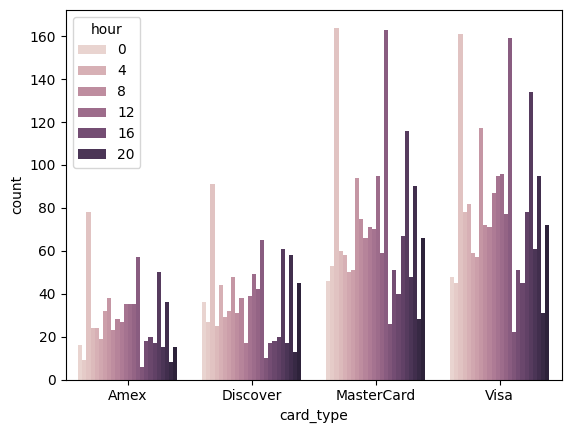

In [156]:
fail_counts = (
    df[df['status'] == 'fail']
    .groupby(['hour', 'card_type'])
    .size()
    .reset_index(name='count')
)

sns.barplot(
    data=fail_counts,
    x='card_type',
    y='count',
    hue='hour'
)

plt.show()

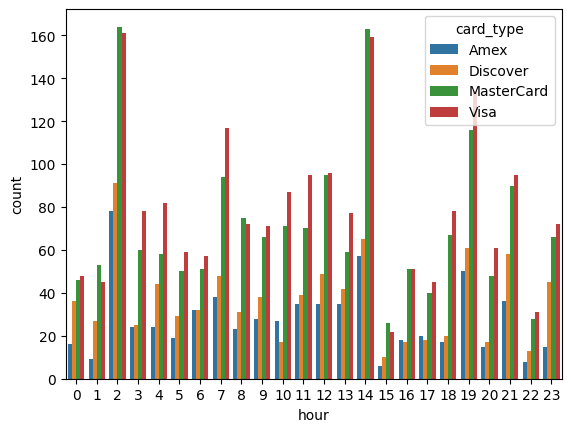

In [157]:
fail_counts = (
    df[df['status'] == 'fail']
    .groupby(['card_type', 'hour'])
    .size()
    .reset_index(name='count')
)

sns.barplot(
    data=fail_counts,
    x='hour',
    y='count',
    hue='card_type'
)

plt.show()

سرویس های مستر کارد و ویزا دارای تراکنش های ناموفق زیادی هستند که بیشتر آنها نیز در ساعات 2 و 14 هستند , این امر میتواند واقعی باشد و باید رفع شود اما اگر دیتا ست اشتباهی به ما داده باشند , احتمال میرود که تاریخ ها نادرست نوشته شده باشد و 14 و 2 هر دو یک منظور داشته باشند (2 بعد از ظهر یا 2 صبح)
در این صورت هیچ کاری نمیتوان کرد زیرا نمیتوان با اطمینان گفت منظور کدام ساعت بوده
بر اساس این پلات اگر پیش بریم , میتوانیم پیک تراکنش ها را پیدا کنیم و در آن زمان کارمندان بیشتری را شیفت کنیم

تمامی پلات ها و خواسته ها و پیشنهاد های مسئله که گفته شده بود , پاسخ داده شد

حل تمرین دیتاست تمرینی از آکادمی تکنوشریف (دانشگاه شریف)
امیدوارم لذت برده باشید و آموخته باشید
برای ارسال کد ها و پیشنهادات و کد هایی که باید اضافه بشه و تحلیل رو کامل تر میکنه , داخل گیتهاب ریکوئست بدید



NoteBook By : AghaSaul (MRXLANTERN)



